# Optimize the base device first, then squeeze; convergent derivatives

## Statement of the problem
The drive amplitude $\epsilon$ and phase $\phi_d$ are set by the drive laser, so they are free parameters of the base device, not fabrication parameters; with the drive phase the effective input strength is $\epsilon_{\rm eff}=\epsilon\sqrt{\cosh 2r-\sinh 2r\cos 2\phi_d}$ (from $\epsilon e^{-r}$ at $\phi_d=0$ to $\epsilon e^{+r}$ at $\phi_d=\pi/2$). The fair question is therefore: **does squeezing improve a device whose drive has already been optimized?**

**Protocol (`run_base.py`).** For each task: (1) scan $\epsilon\in[0.05,1]$ at zero squeezing and keep the best base within a photon budget $\max_t\langle a^\dagger a\rangle\le2.5$ (same budget for the squeezed device; $N_c=12$, checked at 16); (2) scan $(r,r_e,\Delta\theta)$ at $\phi_d=0$ and $(r,r_e)$ grids at $\phi_d=\pi/2$ from that base, masking points over the budget; (3) refine with the convergent gradient. Without the budget the search runs to the truncation limit: the first attempt gave a spurious $-26\%$ on Mackey–Glass at 10–12 photons with a 24% cutoff dependence.

**Convergent derivatives (`common.fd_gradient_conv`).** Richardson extrapolation of central differences at $h$ and $h/2$ with an error estimate, step halved until the error is below 5% of the derivative, second-order one-sided differences inward at box faces (the earlier projected estimator was low by 2–3.4× there). Verified in `run_deriv.py`.

In [1]:
import os, sys, subprocess, numpy as np
CODE = os.path.abspath(os.path.join(os.getcwd(), '..', 'code')); sys.path.insert(0, CODE); os.chdir(CODE); os.environ['OMP_NUM_THREADS'] = '1'
import matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from common import *
import make_figs
RUN = False   # set True to recompute the data for this notebook (see the "Compute" section for the cost)
def show(pdf, dpi=110):
    """Render a figure PDF from paper/figs inline."""
    base = '/tmp/' + os.path.basename(pdf)[:-4]; subprocess.run(['pdftoppm', '-r', str(dpi), '-png', '-singlefile', pdf, base], check=True); display(Image(filename=base + '.png'))
def ld(name):
    p = os.path.join(DATA, name); return np.load(p, allow_pickle=True) if os.path.exists(p) else None


In [2]:
if RUN: subprocess.run(['python3', 'run_base.py']); subprocess.run(['python3', 'run_deriv.py'])
b = ld('base.npz')
for n, name in (('mg', 'Mackey-Glass'), ('narma', 'NARMA10'), ('lorenz', 'Lorenz-63'), ('nce', 'channel eq.'), ('laser', 'Santa Fe laser')):
    E = b[f'{n}_eps']; L02 = E[np.isclose(E[:, 0], 0.2)][0, 1]; Lb = E[:, 1].min(); c = b[f'{n}_conv']
    print('%-16s base eps* = %.2f (%3.0f%% vs eps=0.2) | squeezing on the base: %3.0f%% at (%.2f, %.2f, %.2f), phi_d = %s | photons %.1f, cutoff change %.1f%%' % (name, b[f'{n}_epsbest'], 100 * (1 - Lb / L02), 100 * (1 - c[0, 0] / Lb), *b[f'{n}_best'], 'pi/2' if b[f'{n}_bestpd'] > 0.5 else '0', c[1, 2], 100 * abs(c[0, 0] - c[1, 0]) / c[1, 0]))
dv = ld('deriv.npz')
for r in dv['rows']: print('%-16s fixed %s | convergent %s +- %s | reference %s' % (r[0], np.round(r[2], 6), np.round(r[3], 6), np.round(r[4], 7), np.round(r[6], 6)))

Mackey-Glass     base eps* = 1.00 (  8% vs eps=0.2) | squeezing on the base:   1% at (0.06, 0.05, 2.98), phi_d = pi/2 | photons 1.9, cutoff change 0.0%
NARMA10          base eps* = 0.55 (  7% vs eps=0.2) | squeezing on the base:   6% at (0.24, 0.50, 0.03), phi_d = 0 | photons 2.5, cutoff change 0.1%
Lorenz-63        base eps* = 1.00 ( 90% vs eps=0.2) | squeezing on the base:  67% at (0.05, 0.50, 2.82), phi_d = pi/2 | photons 2.3, cutoff change 0.2%
channel eq.      base eps* = 0.50 ( 56% vs eps=0.2) | squeezing on the base:  59% at (0.40, 0.50, -1.74), phi_d = 0 | photons 2.3, cutoff change 0.4%
Santa Fe laser   base eps* = 0.40 (  8% vs eps=0.2) | squeezing on the base:  65% at (0.50, 0.19, 1.79), phi_d = 0 | photons 2.3, cutoff change 0.3%
interior_mid     fixed [ 1.701e-02 -1.209e-03  2.300e-05] | convergent [ 1.7159e-02 -1.2080e-03  2.3000e-05] +- [3.72e-05 3.00e-07 0.00e+00] | reference [ 1.716e-02 -1.208e-03  2.300e-05]
interior_basin   fixed [1.585e-03 6.300e-04 3.800e-05] | con

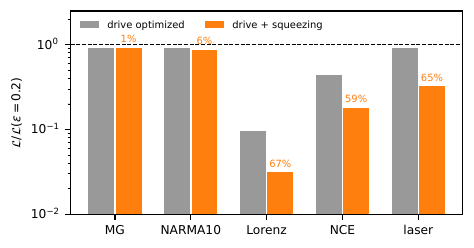

In [3]:
make_figs.fig_base(); show('paper/figs/fig_base.pdf')

Where the fixed-drive gain was an input-strength gain, the optimized drive takes it (Mackey–Glass: +1% left). Where it comes through the emitter — strong external squeezing at small $r$ (NARMA10, Lorenz, NCE) — or through the detuned cavity and counter-rotating coupling (laser, $r\approx0.5$) — squeezing improves even the drive-optimized device by 6–67%. These are the parameters no drive setting reaches.